## Import Libraries
We import the necessary Python modules and PyTorch components that will be used throughout our project.  

**random** :   
    - Useful for controlling random behavior, though not heavily used here.  

**NumPy** :   
    - Complementary numerical library for array operations.  

**PyTorch (torch)** :   
    - Core library for handling tensors, automatic differentiation, and GPU computation. 


**nn and optim** :   
    - Provide pre-built neural network layers (e.g., Conv2d, Linear) and optimization methods (e.g., Adam).  


**torchvision.datasets** :   
    - Simplifies loading common datasets (such as FashionMNIST).  


**torchvision.transforms** :   
    - Preprocessing utilities (e.g., ToTensor()).  


**DataLoader** :   
    - Groups samples into batches for efficient training.  


**torchmetrics** :   
    - Offers ready-to-use metrics (Accuracy, Precision, Recall) that integrate well with PyTorch.  

In [85]:
# -------------------------
# Standard Library Imports
# -------------------------
import random                   # Python's built-in random module
import pandas as pd             # Panda for creating dataframe
import matplotlib.pyplot as plt # Visualizing the image
import seaborn as sns           # Visualizing the chart 

# -------------------------
# Third-Party Library Imports
# -------------------------
import numpy as np            # NumPy for numerical computations
import torch                  # PyTorch for tensor operations
import torch.nn as nn         # Neural network layers and functions
import torch.optim as optim   # Optimization algorithms

# -------------------------
# TorchVision and Transforms
# -------------------------
from torchvision import datasets              # Popular datasets (e.g., ImageFolder)
from torchvision.transforms import transforms # Image transformations (e.g., Resize, Normalize)

# -------------------------
# PyTorch Data Utilities
# -------------------------
from torch.utils.data import Dataset, DataLoader  # Custom dataset creation and batch loading

# -------------------------
# TorchMetrics for Evaluation
# -------------------------
from torchmetrics import Accuracy, Precision, Recall  # Standard evaluation metrics for classification

# -------------------------
# Optuna for Tuning the model
# _________________________
import optuna
from optuna.exceptions import TrialPruned

## Set Seed

In [60]:
# -------------------------
# Set the Seed for Reproducibility
# -------------------------
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

## Define Transformer

In [61]:
# -------------------------
# Define Transformers for Training and Test Datasets
# -------------------------

# Define transforms with augmentation
train_transforms_3 = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(p= 0.5),
    transforms.ColorJitter(brightness= 0.2, contrast= 0.2),
    transforms.ToTensor(),
])

train_transforms_5 = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ColorJitter(brightness= 0.2, contrast= 0.2),
    transforms.ToTensor()
])

transforms_none = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

test_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])


## Load the Dataset
In this step, we download and load the **`FashionMNIST`** dataset, split into a training set (train=True) and a test set (train=False). We specify a root directory (./data) where the data will be stored, and use **`download=True`** to automatically fetch the dataset if it does not exist locally. By applying **`transforms.ToTensor()`**, each image is converted from a PIL image to a normalized PyTorch tensor, simplifying the process of feeding image data into our model.

In [62]:
# -------------------------
# Load the Training and Test Datasets
# -------------------------
train_data = datasets.FashionMNIST(
    root= './data', 
    train= True, 
    download= True, 
    transform= train_transforms_5
)
test_data = datasets.FashionMNIST(
    root= './data', 
    train= False, 
    download= True, 
    transform= test_transforms
)

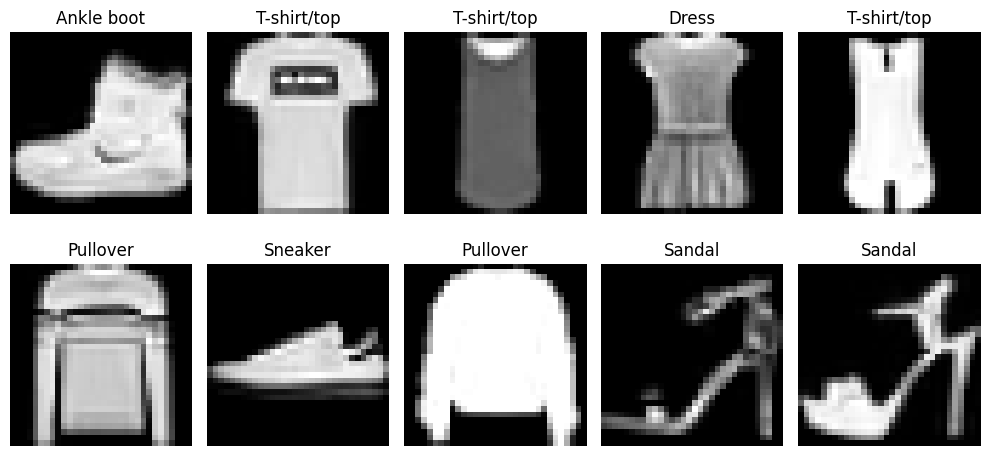

In [63]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))  # Create a 2x5 grid

for i, ax in enumerate(axes.flat):
    image, label = train_data[i]  # Get image and label

    image = image.squeeze().numpy()  # Convert tensor to NumPy

    ax.imshow(image, cmap="gray")

    ax.set_title(f"{train_data.classes[label]}")

    ax.axis("off")

plt.tight_layout()

plt.show()


## Inspect the Dataset
Here, we gather crucial information about our datasets before training. We confirm the number of images available in each split and quickly inspect the shapes of the first training and test samples to ensure they match the expected **`one-channel`**, **`28×28`** **`format`**. We calculate the **`total number of pixels (28 * 28 = 784)`** to understand the raw input dimension for fully connected layers, and we also print out the class labels recognized by **`FashionMNIST`**, ultimately confirming there are **`10 unique categories`** to classify.

In [64]:
# -------------------------
# Basic Dataset Information
# -------------------------
# Print the number of samples in each dataset
print(f"Number of samples in train_data: {len(train_data)}")
print(f"Number of samples in test_data: {len(test_data)}", "\n")

# Inspect the first sample from each dataset
image, label = train_data[0]
image2, label2 = test_data[0]

# Print the shapes of the images
print(f"Train image shape: {image.shape}")
print(f"Test image shape: {image2.shape}", "\n")

# Calculate and print the number of features per image
# For FashionMNIST, each image is 1 channel with size 28 x 28.
num_features = image.shape[1] * image.shape[2]
print(f"Number of features per image: {num_features}", "\n")

# Check and print the available class labels
print(f"Unique class labels in train: {train_data.classes}")
print(f"Unique class labels in test: {test_data.classes}", "\n")
classes = train_data.classes

num_classes = len(train_data.classes)
print(f"Number of unique class labels in train: {num_classes}")

Number of samples in train_data: 60000
Number of samples in test_data: 10000 

Train image shape: torch.Size([1, 32, 32])
Test image shape: torch.Size([1, 32, 32]) 

Number of features per image: 1024 

Unique class labels in train: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
Unique class labels in test: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'] 

Number of unique class labels in train: 10


## Defining the Convolutional Neural Network (CNN) 

This step constructs a **`convolutional neural network (CNN)`** for image classification. It consists of **`two convolutional blocks`** (each followed by ReLU activation and max pooling) that progressively extract spatial features from the input. Using **`Flatten`** transforms the 2D feature maps into a 1D vector, suitable for the final linear (fully connected) layer. We dynamically determine the output size of the feature extraction part by passing a dummy tensor, ensuring that our linear layer’s input dimension matches the extracted feature dimension.


In [65]:
# -------------------------
# Define the CNN Class
# -------------------------
class CNN_net(nn.Module):
    def __init__(self, num_classes):
        super(CNN_net, self).__init__()

        # Feature extraction layers: 
        self.feature_extraction = nn.Sequential(

            # 1) Convolution layer with 16 output channels, kernel 3x3, stride=1, padding=1
            nn.Conv2d(in_channels= 1, out_channels= 16, kernel_size= 3, stride= 1, padding= 1),

            # 2) ReLU activation function
            nn.ReLU(),

            # 3) 2x2 Max Pooling with stride=2
            nn.MaxPool2d(kernel_size= 2, stride= 2),                                                
        )

        # Dynamically compute the number of features after the feature extraction layers.
        with torch.no_grad():
            # Image Size after using nn.Resize()
            image_size = 32    

            # A dummy input
            sample_input = torch.zeros(1, 1, image_size, image_size)     

            # Extract Number of features       
            sample_output = self.feature_extraction(sample_input)

            # Flattened feature size
            num_features = sample_output.view(1, -1).shape[1]

            # Debugging output                                 
            # print("Feature map shape:", sample_output.shape)                    

        # A single fully connected layer to map extracted features to class scores.
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        """
        Forward pass:
        1) Extract features through the convolution, activation, and pooling layers.
        2) Flatten the features into a 1D vector.
        3) Pass the flattened vector to the fully connected layer for classification.
        """
        x = self.feature_extraction(x)    # Convolution & Pooling
        x = torch.flatten(x, start_dim= 1)
        x = self.classifier(x)            # Linear layer
        return x


In [66]:
# -------------------------
# Define the CNN Class
# -------------------------
class CNN_net_2(nn.Module):
    def __init__(self, num_classes):
        super(CNN_net_2, self).__init__()

        # Feature extraction layers: 
        self.feature_extraction = nn.Sequential(

            # 1) Convolution layer with 16 output channels, kernel 3x3, stride=1, padding=1
            nn.Conv2d(in_channels= 1, out_channels= 16, kernel_size= 3, stride= 1, padding= 1),

            # 2) ReLU activation function
            nn.ReLU(),

            # 3) 2x2 Max Pooling with stride=2
            nn.MaxPool2d(kernel_size= 2, stride= 2),

            # 4) Convolution layer with 32 output channels, kernel 3x3, stride=1, padding=1
            nn.Conv2d(in_channels= 16, out_channels= 32, kernel_size= 3, stride= 1, padding= 1),

            # 5) ReLU activation function
            nn.ReLU(),

            # 6) 2x2 Max Pooling with stride=2
            nn.MaxPool2d(kernel_size= 2, stride= 2),                                                 
        )

        # Dynamically compute the number of features after the feature extraction layers.
        with torch.no_grad():
            # Image Size after using nn.Resize()
            image_size = 32    

            # A dummy input
            sample_input = torch.zeros(1, 1, image_size, image_size)     

            # Extract Number of features       
            sample_output = self.feature_extraction(sample_input)

            # Flattened feature size
            num_features = sample_output.view(1, -1).shape[1]

            # Debugging output                                 
            # print("Feature map shape:", sample_output.shape)                    

        # A single fully connected layer to map extracted features to class scores.
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        """
        Forward pass:
        1) Extract features through the convolution, activation, and pooling layers.
        2) Flatten the features into a 1D vector.
        3) Pass the flattened vector to the fully connected layer for classification.
        """
        x = self.feature_extraction(x)    # Convolution & Pooling
        x = torch.flatten(x, start_dim= 1)
        x = self.classifier(x)            # Linear layer
        return x

In [67]:
# -------------------------
# Define the CNN Class
# -------------------------
class CNN_net_3(nn.Module):
    def __init__(self, num_classes):
        super(CNN_net_3, self).__init__()

        # Feature extraction layers: 
        self.feature_extraction = nn.Sequential(

            # 1) Convolution layer with 16 output channels, kernel 3x3, stride=1, padding=1
            nn.Conv2d(in_channels= 1, out_channels= 16, kernel_size= 3, stride= 1, padding= 1),

            # 2) ReLU activation function
            nn.ReLU(),

            # 3) 2x2 Max Pooling with stride=2
            nn.MaxPool2d(kernel_size= 2, stride= 2),

            # 4) Convolution layer with 32 output channels, kernel 3x3, stride=1, padding=1
            nn.Conv2d(in_channels= 16, out_channels= 32, kernel_size= 3, stride= 1, padding= 1),

            # 5) ReLU activation function
            nn.ReLU(),

            # 6) 2x2 Max Pooling with stride=2
            nn.MaxPool2d(kernel_size= 2, stride= 2),

            # 7) Convolution layer with 32 output channels, kernel 3x3, stride=1, padding=1
            nn.Conv2d(in_channels= 32, out_channels= 64, kernel_size= 3, stride= 1, padding= 1),

            # 8) ReLU activation function
            nn.ReLU(),

            # 9) 2x2 Max Pooling with stride=2
            nn.MaxPool2d(kernel_size= 2, stride= 2),                                                  
        )

        # Dynamically compute the number of features after the feature extraction layers.
        with torch.no_grad():
            # Image Size after using nn.Resize()
            image_size = 32    

            # A dummy input
            sample_input = torch.zeros(1, 1, image_size, image_size)     

            # Extract Number of features       
            sample_output = self.feature_extraction(sample_input)

            # Flattened feature size
            num_features = sample_output.view(1, -1).shape[1]

            # Debugging output                                 
            # print("Feature map shape:", sample_output.shape)                    

        # A single fully connected layer to map extracted features to class scores.
        self.classifier = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        """
        Forward pass:
        1) Extract features through the convolution, activation, and pooling layers.
        2) Flatten the features into a 1D vector.
        3) Pass the flattened vector to the fully connected layer for classification.
        """
        x = self.feature_extraction(x)    # Convolution & Pooling
        x = torch.flatten(x, start_dim= 1)
        x = self.classifier(x)            # Linear layer
        return x


## Prepare the Training DataLoader

We now wrap our training dataset in a **`DataLoader`**, which handles batching and data shuffling. Each iteration will yield a batch of **`10`** samples (images and labels), and **`shuffle=True`** ensures that data is randomized each epoch, improving the robustness of training by reducing any unintended ordering effects in the dataset.

In [68]:
# -------------------------
# Define the Training DataLoader and Test DataLoader
# -------------------------
# Create batches of size 10 from the training dataset, and shuffle the data.


def create_dataloader(dataset, batch_size, shuffle) :
    dataloader = DataLoader(
        dataset= dataset,
        batch_size= batch_size,
        shuffle= shuffle
    )

    return dataloader

## Define the Training Function
In this function, we iterate over the **`training data`** for a specified number of epochs, computing and **`backpropagating`** the **`cross-entropy loss`** after each forward pass. The criterion is **`nn.CrossEntropyLoss`**, well-suited to multi-class classification. Each batch updates the model’s parameters through the optimizer (**`optimizer.step()`**), and we track the average loss across all batches per epoch, providing a measure of training progress.

In [69]:
# -------------------------
# Define the Training Function
# -------------------------
def train_model(net, dataloader, optimizer, num_epochs):
    """
    Trains a given neural network for a specified number of epochs.
    
    Parameters:
    -----------
    optimizer: Torch Optimizer
        The optimizer responsible for updating model parameters.
    net: nn.Module
        The neural network model to be trained.
    num_epochs: int
        Number of training epochs.
    
    Returns:
    --------
    None
    """
    # Initialize the loss function
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        running_loss = 0.0  # Accumulate loss over each epoch
        num_processed = 0   # Track how many samples have been processed

        for features, labels in dataloader:
            # Zero out the gradients from the previous iteration
            optimizer.zero_grad()

            # Forward pass
            output = net(features)

            # Calculate loss
            loss = criterion(output, labels)

            # Backward pass
            loss.backward()

            # Update weights
            optimizer.step()

            # Accumulate the loss
            running_loss += loss.item()
            
            # Count the number of processed samples
            num_processed += len(labels)

        # Print the average training loss for this epoch
        train_loss = running_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {train_loss:.4f}")

## Instantiate and Train the Model

Here, we create our **`CNN instance`** and an **`Adam optimizer`**, which is known for its adaptive learning rate and efficient convergence properties. We set the **`learning rate to 0.01`** and call our training function for indicated epochs (more epochs are typically needed for better accuracy). During training, the optimizer updates the CNN’s weights, reducing the cross-entropy loss and hopefully improving model performance.



In [70]:
def evaluate_model(net, dataloader, num_classes):
    """
    Evaluates the model on the given dataloader.
    Returns a dictionary with:
      - "accuracy" (float)
      - "precision_macro" (float)
      - "recall_macro" (float)
      - "precision_per_class" (list)
      - "recall_per_class" (list)
    """
    net.eval()
    
    # 1) Single-scalar metrics
    accuracy_metric = Accuracy(task = 'multiclass', num_classes = num_classes)
    precision_macro = Precision(task = 'multiclass', num_classes = num_classes, average = 'macro')
    recall_macro = Recall(task = 'multiclass', num_classes = num_classes, average = 'macro')
    
    # 2) Per-class metrics
    precision_perclass = Precision(task = 'multiclass', num_classes = num_classes, average = None)
    recall_perclass = Recall(task = 'multiclass', num_classes = num_classes, average = None )
    
    # Accumulate predictions
    with torch.no_grad():
        for features, labels in dataloader:
            outputs = net(features)
            preds = torch.argmax(outputs, dim=-1)

            # Update each metric
            accuracy_metric.update(preds, labels)
            precision_macro.update(preds, labels)
            recall_macro.update(preds, labels)
            precision_perclass.update(preds, labels)
            recall_perclass.update(preds, labels)

    # 3) Compute final metrics
    accuracy_value        = accuracy_metric.compute().item()
    precision_macro_value = precision_macro.compute().item()
    recall_macro_value    = recall_macro.compute().item()
    
    # per-class -> Tensors of shape [num_classes]
    precision_perclass_vals = precision_perclass.compute().tolist()
    recall_perclass_vals    = recall_perclass.compute().tolist()
    
    # Return everything in a dictionary
    results = {
        "accuracy": accuracy_value,
        "precision_macro": precision_macro_value,
        "recall_macro": recall_macro_value,
        "precision_per_class": precision_perclass_vals,
        "recall_per_class": recall_perclass_vals
    }
    
    return results


In [71]:
def train_and_evaluate_multiple_runs(model_class, model_name, transform, transform_name, seeds, num_epochs):
    """
    Runs multiple training/evaluation cycles for a given model class & transform across multiple seeds.
    Returns:
      - summary: Overall mean & std metrics (accuracy, macro precision, macro recall)
      - summary_per_class: Mean & std for per-class precision & recall
    """
    # 1. Prepare train/test datasets with the given transform
    train_dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=test_transforms
    )
    
    dataloader_train = create_dataloader(train_dataset, 20, True)
    dataloader_test = create_dataloader(test_dataset, 20, False)

    # 2. Lists to store MACRO metrics from each run
    acc_scores = []
    prec_mac_scores = []
    rec_mac_scores = []

    # 3. Lists to store per-class precision and recall metrics
    prec_per_class_scores = []
    rec_per_class_scores = []

    # 4. Loop over seeds
    for seed in seeds:
        print(f"\n[Model = {model_name}, Transform = {transform_name}] -- Running with seed={seed}")
        set_seed(seed)
        
        # Fresh model & optimizer each run
        net = model_class(num_classes=10)  # <-- Instantiate your chosen CNN
        optimizer = optim.Adam(net.parameters(), lr=0.001)
        
        # Train
        train_model(net, dataloader_train, optimizer, num_epochs=num_epochs)
        
        # Evaluate -> returns both macro + per-class
        results = evaluate_model(net, dataloader_test, num_classes=10)
        
        # Store macro metrics
        acc_scores.append(results["accuracy"])
        prec_mac_scores.append(results["precision_macro"])
        rec_mac_scores.append(results["recall_macro"])

        # Store per-class precision & recall
        prec_per_class_scores.append(results["precision_per_class"])
        rec_per_class_scores.append(results["recall_per_class"])
        
        print(f"Final Test (seed={seed}) -> "
              f"Acc: {results['accuracy']:.4f}, Prec (macro): {results['precision_macro']:.4f}, "
              f"Rec (macro): {results['recall_macro']:.4f}")

    # 5. Compute summary (overall metrics)
    summary = {
        'model': model_name,
        'transform': transform_name,
        'mean_accuracy': np.mean(acc_scores),
        'std_accuracy': np.std(acc_scores),
        'mean_precision': np.mean(prec_mac_scores),
        'std_precision': np.std(prec_mac_scores),
        'mean_recall': np.mean(rec_mac_scores),
        'std_recall': np.std(rec_mac_scores),
        'num_runs': len(seeds),
    }
    
    # 6. Compute per-class summary
    summary_per_class = {
        'model': model_name,
        'transform': transform_name,
        'mean_precision_per_class': np.mean(prec_per_class_scores, axis=0).tolist(),
        'std_precision_per_class': np.std(prec_per_class_scores, axis=0).tolist(),
        'mean_recall_per_class': np.mean(rec_per_class_scores, axis=0).tolist(),
        'std_recall_per_class': np.std(rec_per_class_scores, axis=0).tolist(),
    }
    
    return summary, summary_per_class


In [72]:
# Example seeds to run multiple times
seeds = np.arange(10, 19, 1).tolist()
# seeds = [1]

# Dictionary of transforms to evaluate
transform_candidates = {
    # "transform_3" : train_transforms_3,
    # "transform_5" : train_transforms_5,
    "transform_none" : transforms_none,
}

# Dictionary of transforms to evaluate
cnn_candidates = {
    "cnn_net" : CNN_net,
    "cnn_net_2" : CNN_net_2,
    "cnn_net_3" : CNN_net_3,
}

# Lists to store results
all_results = []
all_results_per_class = []

# Loop through each Model
for model_name, model_class in cnn_candidates.items():

    # Loop through each transform, run multiple times, collect results
    for transform_name, transform_object in transform_candidates.items():
        
        summary, summary_per_class = train_and_evaluate_multiple_runs(
            model_class= model_class,
            model_name= model_name,
            transform= transform_object,
            transform_name= transform_name,
            seeds= seeds,
            num_epochs= 10
        )

        all_results.append(summary)
        all_results_per_class.append(summary_per_class)

# 1. Create DataFrame for overall results
df_summary = pd.DataFrame(all_results)

# 2. Convert per-class metrics into a structured DataFrame
df_summary_per_class = pd.DataFrame(all_results_per_class)

# Expand lists in `df_summary_per_class` to multiple columns
precision_cols = [f"precision_class_{i}" for i in range(10)]
recall_cols = [f"recall_class_{i}" for i in range(10)]

df_summary_per_class[precision_cols] = pd.DataFrame(df_summary_per_class["mean_precision_per_class"].tolist())
df_summary_per_class[recall_cols] = pd.DataFrame(df_summary_per_class["mean_recall_per_class"].tolist())

# Drop the original list columns since they are now expanded
df_summary_per_class.drop(columns=["mean_precision_per_class", "mean_recall_per_class"], inplace=True)

# (Optional) Save results to CSV
df_summary.to_csv("second_multi_run_summary_with_different_cnn.csv", index=False)
df_summary_per_class.to_csv("second_multi_run_summary_per_class_with_different_cnn.csv", index=False)


[Model = cnn_net, Transform = transform_none] -- Running with seed=10
Epoch 1/10, Training Loss: 0.4212
Epoch 2/10, Training Loss: 0.2852
Epoch 3/10, Training Loss: 0.2435
Epoch 4/10, Training Loss: 0.2150
Epoch 5/10, Training Loss: 0.1912
Epoch 6/10, Training Loss: 0.1706
Epoch 7/10, Training Loss: 0.1539
Epoch 8/10, Training Loss: 0.1397
Epoch 9/10, Training Loss: 0.1255
Epoch 10/10, Training Loss: 0.1129
Final Test (seed=10) -> Acc: 0.9157, Prec (macro): 0.9175, Rec (macro): 0.9157

[Model = cnn_net, Transform = transform_none] -- Running with seed=11
Epoch 1/10, Training Loss: 0.4173
Epoch 2/10, Training Loss: 0.2782
Epoch 3/10, Training Loss: 0.2345
Epoch 4/10, Training Loss: 0.2035
Epoch 5/10, Training Loss: 0.1791
Epoch 6/10, Training Loss: 0.1568
Epoch 7/10, Training Loss: 0.1379
Epoch 8/10, Training Loss: 0.1219
Epoch 9/10, Training Loss: 0.1092
Epoch 10/10, Training Loss: 0.0958
Final Test (seed=11) -> Acc: 0.9099, Prec (macro): 0.9126, Rec (macro): 0.9099

[Model = cnn_net,

In [73]:
df_summary.sort_values(by= "mean_accuracy", ascending= False)

,model,transform,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,num_runs
1,cnn_net_2,transform_none,0.914667,0.002058,0.915792,0.001371,0.914667,0.002058,9
2,cnn_net_3,transform_none,0.914122,0.002600,0.914450,0.002398,0.914122,0.002600,9
0,cnn_net,transform_none,0.911911,0.003062,0.913760,0.002535,0.911911,0.003062,9


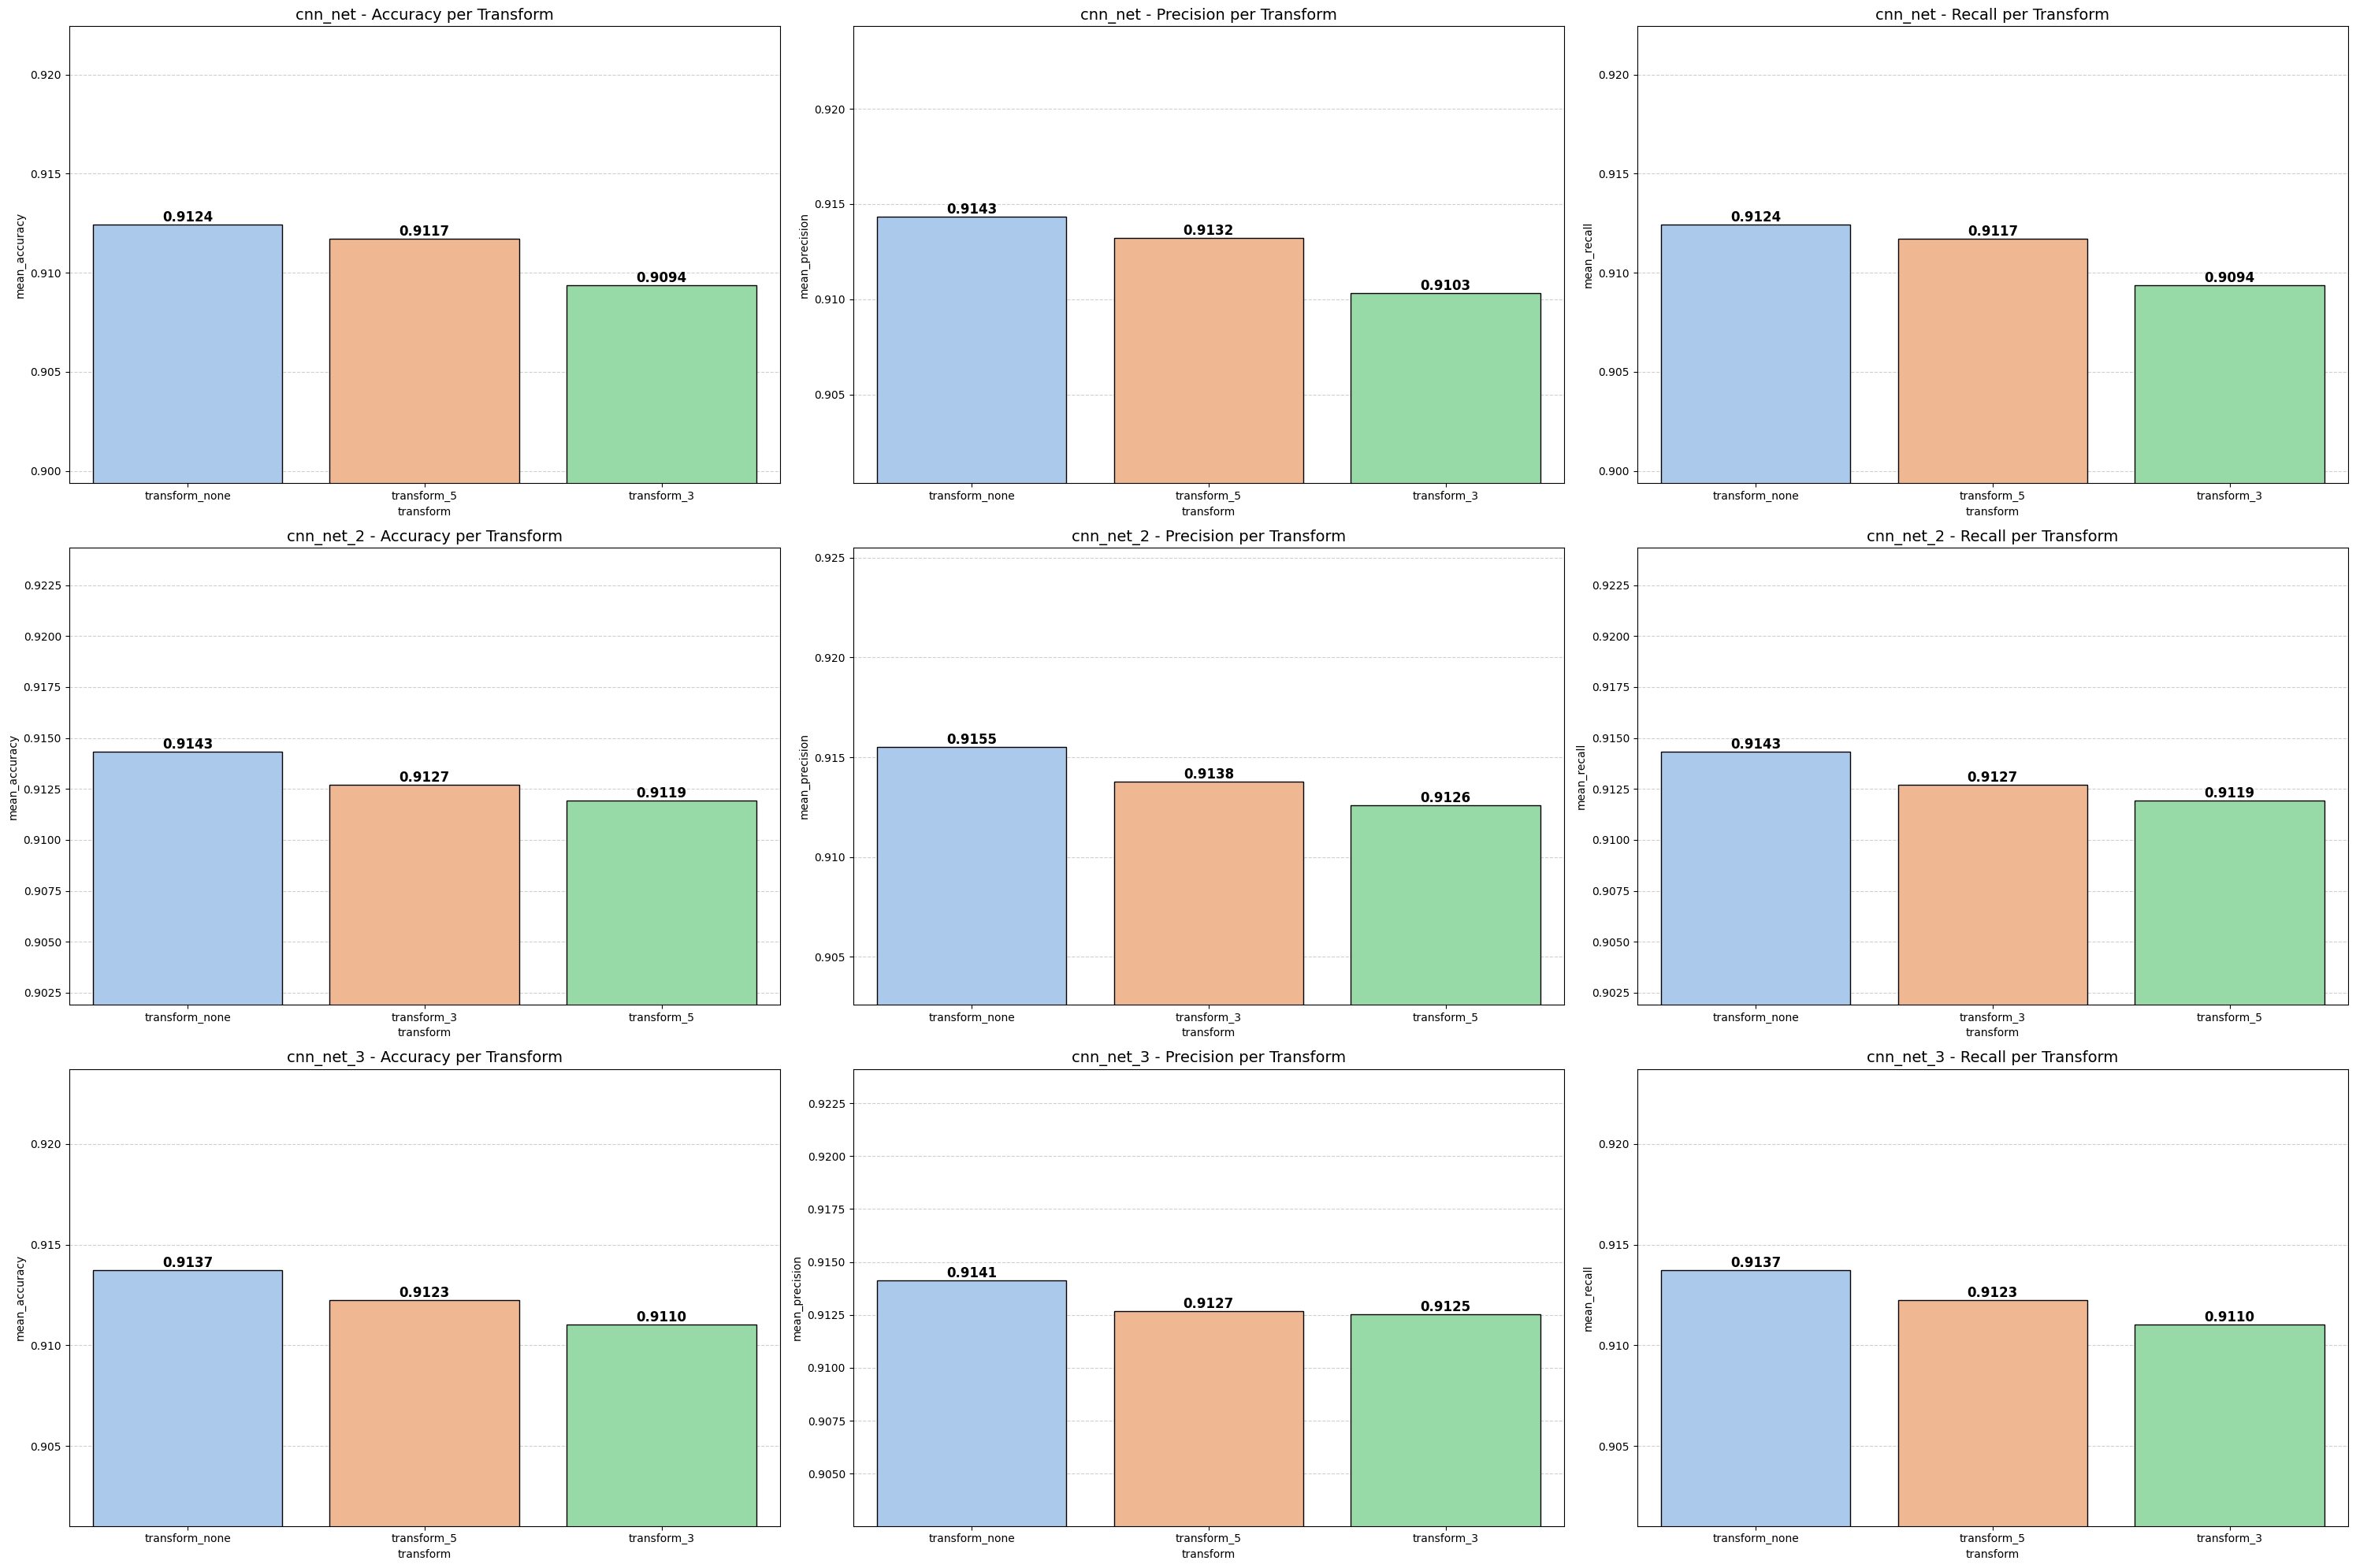

In [80]:
df_summary = pd.read_csv("multi_run_summary_with_different_cnn.csv")

sns.set_palette("pastel")

fig, axes = plt.subplots(3, 3, figsize=(30, 20))

# Unique models (e.g., "cnn_net", "cnn_net_2", "cnn_net_3")
models = df_summary["model"].unique()

metrics = ["mean_accuracy", "mean_precision", "mean_recall"]
titles = ["Accuracy per Transform", "Precision per Transform", "Recall per Transform"]

for row_idx, model in enumerate(models):
    # Filter df_summary to only this model
    df_model = df_summary[df_summary["model"] == model]
    
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx][col_idx]
        
        # Sort by the metric if desired
        df_model_sorted = df_model.sort_values(by=metric, ascending=False)

        sns.barplot(
            data=df_model_sorted,
            x="transform",
            y=metric,
            hue="transform",
            ax=ax,
            edgecolor="black",
            palette="pastel"
        )
        
         # Get min and max values for this metric in this model
        min_val = df_model_sorted[metric].min()
        max_val = df_model_sorted[metric].max()
        
        # Dynamically set y-limit to **zoom in**
        ax.set_ylim(min_val - 0.01, max_val + 0.01)  # Small padding for visibility

        ax.set_title(f"{model} - {titles[col_idx]}", fontsize=14)

        ax.yaxis.grid(True, linestyle="--", alpha=0.6)  # Dashed grid lines
        ax.set_axisbelow(True)  # Ensure grid lines are behind bars

        # Add value labels
        for p in ax.patches:
            ax.annotate(
                f'{p.get_height():.4f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center',
                va='bottom',
                fontsize=12,
                color='black',
                weight="bold"
            )

plt.tight_layout()
plt.show()


/var/folders/sx/x_0znzqn4x19b07rxqhhxxgh0000gn/T/ipykernel_87250/2115918519.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/sx/x_0znzqn4x19b07rxqhhxxgh0000gn/T/ipykernel_87250/2115918519.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/sx/x_0znzqn4x19b07rxqhhxxgh0000gn/T/ipykernel_87250/2115918519.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


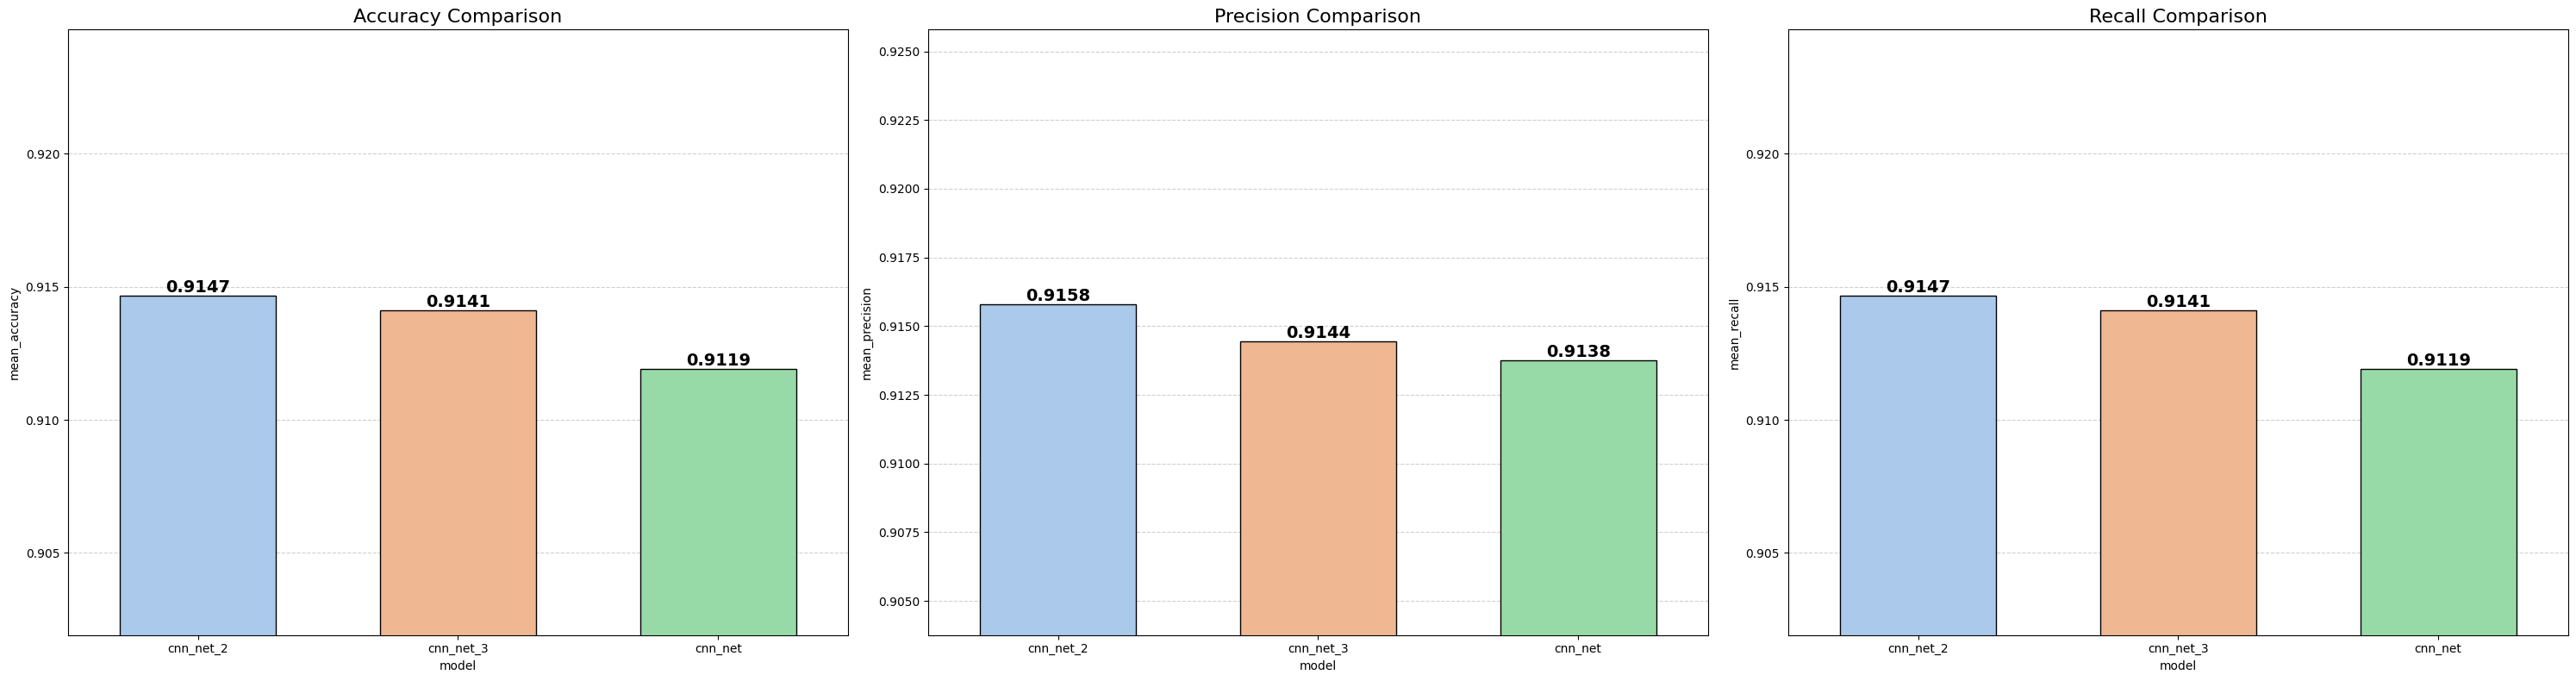

In [81]:
df_summary = pd.read_csv("second_multi_run_summary_with_different_cnn.csv")

sns.set_palette("pastel")

# Create a 1-row, 3-column subplot layout
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

# Unique models
models = df_summary["model"].unique()

# Metrics to compare
metrics = ["mean_accuracy", "mean_precision", "mean_recall"]
titles = ["Accuracy Comparison", "Precision Comparison", "Recall Comparison"]

for col_idx, metric in enumerate(metrics):
    ax = axes[col_idx]

    # Filter only rows with "transform_none"
    df_filtered = df_summary[df_summary["transform"] == "transform_none"]

    # Sort models by the metric for better visualization
    df_filtered_sorted = df_filtered.sort_values(by=metric, ascending=False)

    sns.barplot(
        data=df_filtered_sorted,
        x="model",  # Compare models
        y=metric,
        ax=ax,
        edgecolor="black",
        palette="pastel",
        width=0.6  # Make bars wider
    )

    # Get min and max values for better y-axis scaling
    min_val = df_filtered_sorted[metric].min()
    max_val = df_filtered_sorted[metric].max()

    # Dynamically set y-limits to focus on differences
    ax.set_ylim(min_val - 0.01, max_val + 0.01)

    ax.set_title(titles[col_idx], fontsize=16)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)  # Dashed grid lines
    ax.set_axisbelow(True)

    # Add value labels on top of bars
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.4f}',
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center',
            va='bottom',
            fontsize=14,
            color='black',
            weight="bold"
        )

plt.tight_layout()
plt.show()


In [96]:

def objective(trial) :
    '''
    Define the training + evaluation pipeline for one set of hyperparameters.
    Return the metric (accuracy) we want to maximize
    '''

    # ------------------------------------------------------------------------
    # 1) Choose Which CNN Architecture to use
    # ------------------------------------------------------------------------
    net_name = "cnn_net_2"
    net_class = cnn_candidates[net_name]

    # ------------------------------------------------------------------------
    # 2) Choose Transformer
    # ------------------------------------------------------------------------
    transform_name = "transform_none"
    transform_object = transform_candidates[transform_name]

    # ------------------------------------------------------------------------
    # 3) CHOOSE OTHER HYPERPARAMETERS (e.g., LEARNING RATE, BATCH SIZE)
    # ------------------------------------------------------------------------
    learning_rate = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size    = trial.suggest_categorical("batch_size", [20, 32, 64])
    num_epoch     = 5

    # ------------------------------------------------------------------------
    # 4) Set Seed 
    # ------------------------------------------------------------------------
    set_seed(33)

    # ------------------------------------------------------------------------
    # 5) Create Datasets & Dataloader 
    # ------------------------------------------------------------------------
    # Train dataset with the chosen transform
    train_dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform_object
    )
    test_dataset = datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=test_transforms
    )

    train_loader = create_dataloader(train_dataset, batch_size, shuffle=True)
    test_loader  = create_dataloader(test_dataset,  batch_size, shuffle=False)

    # ------------------------------------------------------------------------
    # 6) Build Model & Optimizer 
    # ------------------------------------------------------------------------
    net = net_class(num_classes= 10)
    optimizer = optim.Adam(net.parameters(), lr=learning_rate)

    # ------------------------------------------------------------------------
    # 7) Train The Model
    # ------------------------------------------------------------------------
    train_model(net, train_loader, optimizer, num_epochs=num_epoch)

    # ------------------------------------------------------------------------
    # 8) Evaluate On the Test Set
    # ------------------------------------------------------------------------
    results = evaluate_model(net, test_loader, num_classes=10)
    accuracy_value = results["accuracy"]

    # Return the accuracy so Optuna can maximize it
    return accuracy_value

In [97]:
def run_optuna_tuning():
    
    # 1) Create a study that tries to maximize the accuracy
    study = optuna.create_study(direction="maximize")

    # 2) Optimize the objective function with a certain number of trials
    study.optimize(objective, n_trials=10)  # Increase n_trials as needed (e.g., 50, 100, ...)

    # 3) Print best result
    print("Number of finished trials:", len(study.trials))
    print("Best trial:", study.best_trial.value)
    print("Best hyperparams:", study.best_params)

    # (Optional) Visualize results if you have optuna[visualization] installed:
    from optuna.visualization import plot_optimization_history, plot_param_importances
    plot_optimization_history(study).show()
    plot_param_importances(study).show()

    return study.best_params


In [98]:
best_params = run_optuna_tuning()

[I 2025-02-09 14:42:58,246] A new study created in memory with name: no-name-319a458d-03d1-4855-b7d5-1bdf1a6d4a73


Epoch 1/5, Training Loss: 0.4426
Epoch 2/5, Training Loss: 0.2864
Epoch 3/5, Training Loss: 0.2431
Epoch 4/5, Training Loss: 0.2182
Epoch 5/5, Training Loss: 0.1924


[I 2025-02-09 14:45:54,781] Trial 0 finished with value: 0.9067000150680542 and parameters: {'learning_rate': 0.002146258909989707, 'batch_size': 32}. Best is trial 0 with value: 0.9067000150680542.


Epoch 1/5, Training Loss: 0.8610
Epoch 2/5, Training Loss: 0.5499
Epoch 3/5, Training Loss: 0.4751
Epoch 4/5, Training Loss: 0.4311
Epoch 5/5, Training Loss: 0.4009


[I 2025-02-09 14:48:16,890] Trial 1 finished with value: 0.8517000079154968 and parameters: {'learning_rate': 0.00010045469121988145, 'batch_size': 64}. Best is trial 0 with value: 0.9067000150680542.


...

Epoch 1/5, Training Loss: 0.5012
Epoch 2/5, Training Loss: 0.3083
Epoch 3/5, Training Loss: 0.2657
Epoch 4/5, Training Loss: 0.2349
Epoch 5/5, Training Loss: 0.2110


[I 2025-02-09 15:08:01,790] Trial 8 finished with value: 0.9074000120162964 and parameters: {'learning_rate': 0.0016033458431767222, 'batch_size': 64}. Best is trial 5 with value: 0.9121999740600586.


Epoch 1/5, Training Loss: 0.4277
Epoch 2/5, Training Loss: 0.2907
Epoch 3/5, Training Loss: 0.2551
Epoch 4/5, Training Loss: 0.2320
Epoch 5/5, Training Loss: 0.2144


[I 2025-02-09 15:10:56,965] Trial 9 finished with value: 0.9025999903678894 and parameters: {'learning_rate': 0.003660842022751147, 'batch_size': 32}. Best is trial 5 with value: 0.9121999740600586.


Number of finished trials: 10
Best trial: 0.9121999740600586
Best hyperparams: {'learning_rate': 0.0009341637921477334, 'batch_size': 20}


In [100]:
best_params

{'learning_rate': 0.0009341637921477334, 'batch_size': 20}

In [101]:
def train_and_evaluate_multiple_runs(model_class, model_name, transform, transform_name, seeds, num_epochs):
    """
    Runs multiple training/evaluation cycles for a given model class & transform across multiple seeds.
    Returns:
      - summary: Overall mean & std metrics (accuracy, macro precision, macro recall)
      - summary_per_class: Mean & std for per-class precision & recall
    """
    # 1. Prepare train/test datasets with the given transform
    train_dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )
    test_dataset = datasets.FashionMNIST(
        root='./data',
        train=False,
        download=True,
        transform=test_transforms
    )
    
    dataloader_train = create_dataloader(train_dataset, best_params["batch_size"], True)
    dataloader_test = create_dataloader(test_dataset, best_params["batch_size"], False)

    # 2. Lists to store MACRO metrics from each run
    acc_scores = []
    prec_mac_scores = []
    rec_mac_scores = []

    # 3. Lists to store per-class precision and recall metrics
    prec_per_class_scores = []
    rec_per_class_scores = []

    # 4. Loop over seeds
    for seed in seeds:
        print(f"\n[Model = {model_name}, Transform = {transform_name}] -- Running with seed={seed}")
        set_seed(seed)
        
        # Fresh model & optimizer each run
        net = model_class(num_classes=10)  # <-- Instantiate your chosen CNN
        optimizer = optim.Adam(net.parameters(), lr= best_params["learning_rate"])
        
        # Train
        train_model(net, dataloader_train, optimizer, num_epochs=num_epochs)
        
        # Evaluate -> returns both macro + per-class
        results = evaluate_model(net, dataloader_test, num_classes=10)
        
        # Store macro metrics
        acc_scores.append(results["accuracy"])
        prec_mac_scores.append(results["precision_macro"])
        rec_mac_scores.append(results["recall_macro"])

        # Store per-class precision & recall
        prec_per_class_scores.append(results["precision_per_class"])
        rec_per_class_scores.append(results["recall_per_class"])
        
        print(f"Final Test (seed={seed}) -> "
              f"Acc: {results['accuracy']:.4f}, Prec (macro): {results['precision_macro']:.4f}, "
              f"Rec (macro): {results['recall_macro']:.4f}")

    # 5. Compute summary (overall metrics)
    summary = {
        'model': model_name,
        'transform': transform_name,
        'mean_accuracy': np.mean(acc_scores),
        'std_accuracy': np.std(acc_scores),
        'mean_precision': np.mean(prec_mac_scores),
        'std_precision': np.std(prec_mac_scores),
        'mean_recall': np.mean(rec_mac_scores),
        'std_recall': np.std(rec_mac_scores),
        'num_runs': len(seeds),
    }
    
    # 6. Compute per-class summary
    summary_per_class = {
        'model': model_name,
        'transform': transform_name,
        'mean_precision_per_class': np.mean(prec_per_class_scores, axis=0).tolist(),
        'std_precision_per_class': np.std(prec_per_class_scores, axis=0).tolist(),
        'mean_recall_per_class': np.mean(rec_per_class_scores, axis=0).tolist(),
        'std_recall_per_class': np.std(rec_per_class_scores, axis=0).tolist(),
    }
    
    return summary, summary_per_class


In [105]:
seeds = np.arange(10, 19, 1).tolist()

all_results = []
all_results_per_class = []

summary, summary_per_class = train_and_evaluate_multiple_runs(
    model_class= CNN_net_2,
    model_name= "cnn_net_2",
    transform= transforms_none,
    transform_name= "transform_none",
    seeds= seeds,
    num_epochs= 10
)

all_results.append(summary)
all_results_per_class.append(summary_per_class)

# 1. Create DataFrame for overall results
df_summary = pd.DataFrame(all_results)

# 2. Convert per-class metrics into a structured DataFrame
df_summary_per_class = pd.DataFrame(all_results_per_class)

# Expand lists in `df_summary_per_class` to multiple columns
precision_cols = [f"precision_class_{i}" for i in range(10)]
recall_cols = [f"recall_class_{i}" for i in range(10)]

df_summary_per_class[precision_cols] = pd.DataFrame(df_summary_per_class["mean_precision_per_class"].tolist())
df_summary_per_class[recall_cols] = pd.DataFrame(df_summary_per_class["mean_recall_per_class"].tolist())

# Drop the original list columns since they are now expanded
df_summary_per_class.drop(columns=["mean_precision_per_class", "mean_recall_per_class"], inplace=True)

# (Optional) Save results to CSV
df_summary.to_csv("Final_multi_run_summary.csv", index=False)
df_summary_per_class.to_csv("Final_multi_run_summary_per_class.csv", index=False)


[Model = cnn_net_2, Transform = transform_none] -- Running with seed=10
Epoch 1/10, Training Loss: 0.4505
Epoch 2/10, Training Loss: 0.2925
Epoch 3/10, Training Loss: 0.2444
Epoch 4/10, Training Loss: 0.2121
Epoch 5/10, Training Loss: 0.1863
Epoch 6/10, Training Loss: 0.1653
Epoch 7/10, Training Loss: 0.1486
Epoch 8/10, Training Loss: 0.1310
Epoch 9/10, Training Loss: 0.1172
Epoch 10/10, Training Loss: 0.1053
Final Test (seed=10) -> Acc: 0.9068, Prec (macro): 0.9114, Rec (macro): 0.9068

[Model = cnn_net_2, Transform = transform_none] -- Running with seed=11
Epoch 1/10, Training Loss: 0.4618
Epoch 2/10, Training Loss: 0.2956
Epoch 3/10, Training Loss: 0.2462
Epoch 4/10, Training Loss: 0.2160
Epoch 5/10, Training Loss: 0.1936
Epoch 6/10, Training Loss: 0.1721
Epoch 7/10, Training Loss: 0.1572
Epoch 8/10, Training Loss: 0.1430
Epoch 9/10, Training Loss: 0.1287
Epoch 10/10, Training Loss: 0.1187
Final Test (seed=11) -> Acc: 0.9178, Prec (macro): 0.9195, Rec (macro): 0.9178

[Model = cnn_

In [106]:
df_summary

,model,transform,mean_accuracy,std_accuracy,mean_precision,std_precision,mean_recall,std_recall,num_runs
0,cnn_net_2,transform_none,0.9142,0.003687,0.915584,0.002951,0.9142,0.003687,9
